# Logistic Regression, SVM

## Binary Logistic Regression

The goal of this section is to analyze the performance of the Binary Logistic Regression Model on our dataset. <br>
The binary L.R. model is, despite its name, a classification model. If with GGM our goal was to model the distrIbution of samples given the classes, $X \mid C$, in this case we want to directly model the posterior distributions of the classes $C \mid X$. So, with the binary L.R. model we aim at modelling:
$$
P(C = 1 \mid \mathbf{x})
$$
$$
P(C = 0 \mid \mathbf{x}) = 1 - P(C = 1 \mid \mathbf{x})
$$
We can assume that the separation surface between classes is linear, so it's an hyperplane, so the decision function will be linear wrt to features $\mathbf{x}$:
$$
s(\mathbf{x}, \mathbf{w}, b) = \mathbf{w}^T \mathbf{x} + b \gtrless t
$$
here $(\mathbf{w}, b)$ are the model parameters, which geometrically describe the hyperplane: $\mathbf{w}$ (*weights vector*) is the vector orthogonal to it and which determines its direction, and $b$ is the *bias* (or *intercept*), so it's a scalar which tells us how long we move along the direction of $\mathbf{w}$, from the origin (so, if $b = 0$, the hyerplane passes through the origin). <br>
The classification rule for a test sample $x_t$ is comparing the score $s(\mathbf{x}_t, \mathbf{w}, b)$ with a treshold $t$. If the application prior $\pi_T$ is equal to the empirical prior from the training set $\pi_{emp}^{LTR}$, and if we assume uniform costs for the two errors, the classification rule resolves in comparig the score with zero:
$$
s(\mathbf{x_t}, \mathbf{w}, b) = \mathbf{w}^T \mathbf{x}_t + b \gtrless 0
$$
So here $s(\mathbf{x}, \mathbf{w}, b) = \mathbf{w}^T \mathbf{x} + b = 0$ is the decision surface which separates the two classes. If $s(\mathbf{x_t}, \mathbf{w}, b) > 0$, $x_t$ will get label 1, otherwise 0. <br>
The score can be written as the log posterior ratio:
$$
s(\mathbf{x}, \mathbf{w}, b) = \log \frac{P(C = 1 \mid \mathbf{x}, \mathbf{w}, b)}{P(C = 0 \mid \mathbf{x}, \mathbf{w}, b)}
$$
Remember that the log posterior ratio can in turn be written, using Bayes' Theorem, by the sum of the log likelihood ratio ($\text{llr}(\mathbf{x})$) and the prior log odds:
$$
s(\mathbf{x}, \mathbf{w}, b) = \log \frac{P(C = 1 \mid \mathbf{x}, \mathbf{w}, b)}{P(C = 0 \mid \mathbf{x}, \mathbf{w}, b)} = \log \frac{f_{X \mid C}(\mathbf{x} \mid C=1)}{f_{X \mid C}(\mathbf{x} \mid C=1)} + \log \frac{\pi}{1-\pi}
$$
So by exponentiating the first equation and solving it, having in mind that the two probabilities add up to $1$:
$$
\frac{P(C=1 \mid \mathbf{x}, \mathbf{w}, b)}{P(C=0 \mid \mathbf{x}, \mathbf{w}, b)} = e^{(\mathbf{w}^T \mathbf{x} + b)}
$$
We can find:
$$
P(C = 1 \mid \mathbf{x}, \mathbf{w}, b) = \frac{1}{1 + e^{- (\mathbf{w}^T + b)}} = \sigma(\mathbf{w}^T \mathbf{x} + b)
$$
$$
P(C = 0 \mid \mathbf{x}, \mathbf{w}, b) = 1 - P(C = 1 \mid \mathbf{x}, \mathbf{w}, b) = 1 - \sigma(\mathbf{w}^T \mathbf{x} + b) = \sigma(- (\mathbf{w}^T \mathbf{x} + b))
$$
The function $\sigma(t) = \frac{1}{1 + e^{-t}}$ is the **sigmoid**: it spans from 0 to 1 and has these properties:
- $\lim\limits_{t \rightarrow \infty} \sigma(t) = 1$
- $\lim\limits_{t \rightarrow - \infty} \sigma(t) = 0$
- $1- \sigma(t) = \sigma(- t)$

So, considering a test sample $\mathbf{x}_i$, we want to model the posteriors:
$$
P(C_i = 1 \mid \mathbf{x}_i, \mathbf{w}, b) = \sigma(\mathbf{w}^T \mathbf{x}_i + b)
$$
$$
P(C_i = 0 \mid \mathbf{x}_i, \mathbf{w}, b) = \sigma(- (\mathbf{w}^T \mathbf{x}_i + b))
$$
We can thus say that $C_i$ will assume value $1$ with probability $\sigma(\mathbf{w}^T \mathbf{x}_i + b)$, and value $0$ with probability $\sigma(- (\mathbf{w}^T \mathbf{x}_i + b))$ = $1 - \sigma(\mathbf{w}^T \mathbf{x}_i + b)$. So we can say that the distrubutions of labels wrt features and model parameters is a **Bernoulli distribution**:
$$
C_i \mid X_i, \mathbf{w}, b \sim \text{Bern}(\sigma(\mathbf{w}^T \mathbf{x}_i + b))
$$
The goal of training is to find a set of model parameters $(\mathbf{w}, b)$ which **best describes the observed labels on our dataset** (note that this is different from GGM where the goal was to find model parameters which best described the distribution of our data!). <br>
So, formalizing this, we start by assuming to have at our disposal a labeled dataset:
$$
\mathcal{D} = \left[ \left( x_1, c_1\right); ... ; \left( x_N, c_N\right) \right]
$$
We can assume classes are independently ditributed (however, they are **not** *i.i.d.* anymore, since in this case they depend on the specific sample $x_i$):
$$
C_i \mid \mathbf{x}_i, \mathbf{w}, b \sim C \mid \mathbf{x}_i, \mathbf{w}, b
$$
We can follow the frequentist approach and apply the **MLE**. So, we can compute the Likelihood:
$$
\mathcal{L} = P(C_1, ..., C_N \mid X_1, ... , X_N, \mathbf{w}, b) = \prod_{i=1}^{n} P(C_i = c \mid X_i = x_i, \mathbf{w}, b)
$$
Since the distributions are Bernoulli:
$$
\mathcal{L}(\mathbf{w}, b) = \prod_{i=1}^{n} \sigma(\mathbf{w}^T \mathbf{x}_i + b)^{c_i} \cdot (1 - \sigma(\mathbf{w}^T \mathbf{x}_i + b))^{(1 - c_i)}
$$
To simplify the notation we can call $y_i = \sigma(\mathbf{w}^T \mathbf{x}_i + b)$ (so, $y_i$ are the predicted labels):
$$
\mathcal{L}(\mathbf{w}, b) = \prod_{i=1}^{n} y_{i}^{c_i} \cdot (1 - y_i)^{(1 - c_i)}
$$
It's always more practical to work in the *log-domain*:
$$
\ell(\mathbf{w}, b) = \sum_{i = 1}^{n}\left[ c_i \log{y_i} + (1-c_i) \log(1- y_i) \right]
$$
So, the goal is to find the best model parameters $(\mathbf{w}^*, b^*)$ that maximize $\ell(\mathbf{w}, b)$. <br>
Now, $\ell(\mathbf{w}, b)$ is the first objective function interpretation. We can give another two interpretations. <br>

The first one is the **average cross-entropy** between the actual and predicted labels, which is the negative of $\ell(\mathbf{w}, b)$, apart from the $\frac{1}{n}$ term used to compute the average:
$$
\mathcal{J}(\mathbf{w}, b) = - \frac{1}{n} \sum_{i = 1}^{n}\left[ c_i \log{y_i} + (1-c_i) \log(1- y_i) \right]
$$
The cross-entropy between two distribution, $P$ and $Q$ is defined as such:
$$
H(P, Q) = -\mathbb{E}_{P(x)}\left[\log Q(x)\right]
$$
So, this is minimized when $P = Q$, so when the two distrubutions are equivalent. <br>
In our context, $\mathcal{J}(\mathbf{w}, b)$ tells us how far is the distribution of the labels predicted by our Recognizer $\mathcal{R}$, from the distributions of the actual labels, known by an observer ${\Large \varepsilon}$. So, long story short, minimizing this objective function means that **we want our predicted labels to be as similar as possible (ideally exactly equal) to the actual labels**. <br>

Another interpretation is the **average Logistic Loss function**, which is derived by the average cross-entropy by means of some semplifications (like writing the sigmoid complete formula) and this substitution: $z_i = 2 c_i - 1$:
$$
\mathcal{J}(\mathbf{w}, b) = \frac{1}{n} \sum_{i = 1}^{n} \log\left( 1 + e^{- z_i (\mathbf{w}^T \mathbf{x}_i + b)}\right)
$$
The function $\mathcal{l}(x) = \log\left( 1 + e^{- x}\right)$ is the Logistic Loss. <br>
This defines an **empirical risk**: it's empirical because it's related to potential missclassification errors, or even related to the cases where the classification is correct but not so certain (i.e. the point is very near the decision boundary). In fact, $\mathcal{l}(x)$ is asympthotically exponentially decreasing for $x > 0$ and asympthotically linearly increasing for $x \leq 0$. This means that for correctly classified samples we would have $z_i s_i > 0$, so the loss would exponentially decrase, depending on how far the correctly classified point is wrt the decision boundary, whereas for missclassified samples we would have $z_i s_i < 0$, so the loss would linearly get bigger and bigger, depending on how much we're wrong (i.e. how far from the decision boundary the missclassified point is). So in this case, minimizing the average Logistic Loss function means that we aim at a good, correct classification, so that the function is as low as possibile. Also, as already said, note that if a point gets correctlky classified but sits very near the classification rule, the loss won't be so small since there exist this uncertainity in classification, which is a risk. <br>

There are some limitations of this model. <br>
The first one is that, in the case where classes are **exactly separable** (which could seem the perfecty case for this model but in reality it's not!) the solution is **undefined**: in this case we cuould arbitrarily minimize the logistic loss function by incrementing the score, so incrementing the norm of $\mathbf{w}$ or the bias. In fact, remember that $\mathbf{w}^T \mathbf{x} + b$ is the decision surface if put $= 0$,  but also tell us how far from it a test point sits if it's either $> 0$ or $< 0$. So in this case the optimal solution would correspond to $\|\mathbf{w}\| \rightarrow \infty$. To overcome this problem we can artificially introduce a norm penalty term (also called regularization term) in the objective function, which is dependent on the hyperparameter $\lambda$:
$$
\frac{\lambda}{2} \|\mathbf{w}\|^2
$$
We can say that this forces to model to find simpler (so, more uncertain depending on the magnitude of $\lambda$) solution, but we avoid having $\|\mathbf{w}\| \rightarrow \infty$ in any cases. <br> Remember that if $\lambda$ gets too high, the class separation gets bad and the error rate increases, on the other hand if $\lambda$ gets too small, the model will make more confident solutions but will probably become over confident, leading to poor generalization when applied to validation sets, and overfitting. <br>

Another limitation of this model is that, since it directly computes posteriors, it is very infuenced by the empirical prior of the training dataset, $\pi_{emp}^{LTR}$. This can be an issue if we want to use applications having very different priors. In this case we can solve this by following two approaches. <br>
1) In the first approach we can manually subtract the empirical prior log odds of the training set from the score, making it resemble a log-likelihood ratio:
    $$
    s_{llr}(\mathbf{x}, \mathbf{w}, b) = \mathbf{w}^T \mathbf{x} + b - \log \frac{\pi_{emp}^{LTR}}{1-\pi_{emp}^{LTR}}
    $$
    Then as classification rule we can compare this "llr like" score with the application prior log odds:
    $$
    s_{llr}(\mathbf{x}, \mathbf{w}, b) \gtrless \log \frac{\pi_{T}}{1-\pi_{T}}
    $$
2) In the second, genarally better, approach we operate directly at the objective function level, modelling a new objective function that is more sensitive to the application prior $\pi_T$ and which accounts for the relative contribution of each sample, by introducing a class-weight term. This approach is called **prior-weighted logistic regression**. Take for example the prior-weighted (also regularized for completeness) Logistic Loss function:
    $$
    \mathcal{J}(\mathbf{w}, b) = \frac{\lambda}{2} \|\mathbf{w}\|^2 + \sum_{i = 1}^{n} \xi_i \log \left( 1 + e^{-z_i (\mathbf{w}^T \mathbf{x}_i + b)}\right)
    $$
    Here we don't average the loss over all samples, as with the standard objective function, but we introduce the class weight $\xi_i$ which is proportional to target class priors and inversely proportional to the empirical frequency of that class in the training set:
    $$
    \xi_i = 
    \begin{cases}
    \frac{\pi_T}{n_T} \text{ if } z_i = 1 \\
    \frac{1-\pi_T}{n_F} \text{ if } z_i = -1
    \end{cases}
    $$
    where $n_T$ and $n_F = 1 - n_T$ are the number of samples belonging to each class.


So, having brifly explained the theory under this L.R. model, we can start considering the standard, non weighted version of it, without any pre-processing (like PCA). We just apply the regularization term and, because of the fact we want to use our primary application prior prior $\pi_T = 0.1$, which is different from the empirical prior of the training set, $\pi_{emp}^{LTR}$, we remove the empirical training set prior log odds from the computed scores (so, we apply the first approach explained before, without proper application prior weighting at the objective function level).

So, we first import the libraries we need and the default train-validation split (train percentage is $2/3$ of the total samples) used for the other previous models:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys


logRegPath = './models/logreg'
if not logRegPath in sys.path:
    sys.path.append(logRegPath)

import LR #LR model

spitPath = './split/split_data.npz'
savedSplit = np.load(spitPath)

DTR = savedSplit['DTR']
DVAL = savedSplit['DVAL']
LTR = savedSplit['LTR']
LVAL = savedSplit['LVAL']

print(f"DTR shape: {DTR.shape}")
print(f"DVAL shape: {DVAL.shape}")
print(f"LTR shape: {LTR.shape}")
print(f"LVAL shape: {LVAL.shape}")

DTR shape: (6, 4000)
DVAL shape: (6, 2000)
LTR shape: (4000,)
LVAL shape: (2000,)


We can test the model using different regularization terms, so different $\lambda$. Remember that:
- if $\lambda$ is too small, the norm penalty has less influence in the objective, leading to an over confident model which will make confident solutions on the training set, but may have poor generalization on unseen data, thus leading to overfitting.
- if $\lambda$ is too high, the norm penalty becomes a too strong contraint, so the class separation can get bad and the error rate can increase.

So, it's better to test the influence of $\lambda$ especially at every magnitude order of it. To do so, we can use different $\lambda_t$, evenly spaced on a log scale that goes from -4 to 2, using 13 points. This way, we start testing with $\lambda_t \approx 10^{-4}$, up to $\lambda_t \approx 100$, examinating every magnitude order between them, while also having intermediate points approximately near halfway between these orders of magnitude on the log scale.

In [2]:
#define lambda log-space
lambdas = np.logspace(-4, 2, 13)
print(f"lambdas: {lambdas}")

lambdas: [1.00000000e-04 3.16227766e-04 1.00000000e-03 3.16227766e-03
 1.00000000e-02 3.16227766e-02 1.00000000e-01 3.16227766e-01
 1.00000000e+00 3.16227766e+00 1.00000000e+01 3.16227766e+01
 1.00000000e+02]


In this case, since we have a large dataset, to speed up the computations it's better to manually compute the gradient of the objective function, wqhen training our model. The gradient of the objective function (avg. Logistic LOss function):
$$
\mathcal{J}(\mathbf{w}, b) = \frac{\lambda}{2} \|\mathbf{w}\|^2 + \frac{1}{n} \sum_{i=1}^{n} \log (1 + e^{-z_i(\mathbf{w}^T \mathbf{x}_i + b)}), \quad z_i = \begin{cases} 1 & \text{if } c_i = 1 \\ -1 & \text{if } c_i = 0 \end{cases} \quad (i.e. \ z_i = 2c_i - 1) \quad (2)
$$

is this:

$$
\nabla_{\mathbf{w}} J = \left[\frac{\partial J}{\partial w_1} \cdots \frac{\partial J}{\partial w_d}\right] = \lambda \mathbf{w} + \frac{1}{n} \sum_{i=1}^{n} \frac{-z_i}{1 + e^{z_i(\mathbf{w}^T \mathbf{x}_i + b)}} \mathbf{x}_i
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} \frac{-z_i}{1 + e^{z_i(\mathbf{w}^T \mathbf{x}_i + b)}}
$$

Also, remember that, since our appliation prior is different from the empirical one of the training set, we end up subtracting the empirical prior log odds from the computed scores, to recover "log-likelihood ratio" style score, which will be thresholded with the application prior log odds to build the decision rule:
$$
P_{emp}(C = h_1) = \frac{\sum_{c_i=1}c_i}{K} = \frac{\sum_{i=0}^{K-1}c_i}{K} = \frac{n_{h_1}}{K} \\\\
P_{emp}(C = h_0) = 1 - P_{emp}(C = h_1) = \frac{\sum_{c_i=0}c_i}{K} = 1 - \frac{n_{h_1}}{K} = \frac{n_{h_0}}{K}
$$
$$
\log \frac{P_{emp}(C = h_1)}{P_{emp}(C = h_0)} = \log \frac{n_{h_1} / K}{n_{h_0} / K} = \frac{n_{h_1}}{n_{h_0}}
$$
$$
s_{llr}(\mathbf{x}) = s(\mathbf{x}) - \log \frac{n_{h_1}}{n_{h_0}} = \mathbf{w}^T \mathbf{x} + b - \log \frac{\pi_{emp}^{LTR}}{1- \pi_{emp}^{LTR}}
$$
The log posterior ratio is thus:
$$
\log \frac{P_{app}(C = h1 \mid \mathbf{x}, \mathbf{w}, b)}{P_{app}(C = h0 \mid \mathbf{x}, \mathbf{w}, b)} = s_{llr}(\mathbf{x}) + \log \frac{\pi_T}{1 - \pi_T} = \mathbf{w}^T \mathbf{x} + b - \log \frac{\pi_{emp}^{LTR}}{1- \pi_{emp}^{LTR}} + \log \frac{\pi_T}{1 - \pi_T}
$$
So to compute decisions we just do:
$$
s_{llr}(\mathbf{x}) \gtrless \log \frac{\pi_T}{1 - \pi_T}
$$
This provides a decision rule that is adapted to the specific prior of the target application. The threshold $\log \frac{\pi_T}{1 - \pi_T}$
represents the point where the posterior probability for class $h_1$ is equal to the application prior $\pi_T$.

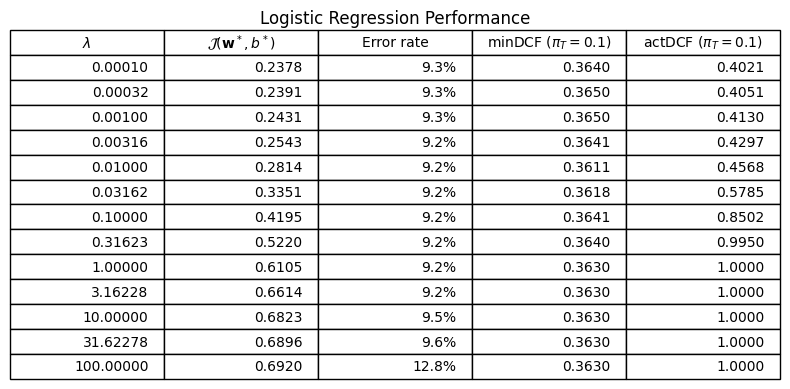

In [3]:
#train and fit binary logistic regression model
AppPriorTrue = 0.1
(_, _, minDCF_l, DCF_l, _) = LR.fitLogReg(DTR, LTR, DVAL, LVAL, lambdas, AppPriorTrue, manual_grad=True)

In [ ]:
#they are dictionaries with keys as the lambda values, values as the minDCF/DCF
print(f"minDCF_l: {minDCF_l}")
print(f"DCF_l: {DCF_l}")

minDCF_l: {0.0001: 0.36397529441884274, 0.00031622776601683794: 0.3649673579109063, 0.001: 0.3649673579109063, 0.0031622776601683794: 0.36411930363543266, 0.01: 0.3611431131592422, 0.03162277660168379: 0.36184715821812596, 0.1: 0.36411930363543266, 0.31622776601683794: 0.36397529441884274, 1.0: 0.36298323092677925, 3.1622776601683795: 0.36298323092677925, 10.0: 0.36298323092677925, 31.622776601683793: 0.36298323092677925, 100.0: 0.36298323092677925}
DCF_l: {0.0001: 0.40208973374295953, 0.00031622776601683794: 0.40506592421915, 0.001: 0.4130024321556579, 0.0031622776601683794: 0.42972350230414746, 0.01: 0.4567812339989759, 0.03162277660168379: 0.5785170250896057, 0.1: 0.8501984126984127, 0.31622776601683794: 0.9950396825396826, 1.0: 1.0, 3.1622776601683795: 1.0, 10.0: 1.0, 31.622776601683793: 1.0, 100.0: 1.0}


We can now plot the $\text{DCF}$ and $\text{min DCF}$ as functions of te hyperparameter $\lambda$, using a logarithmic scale for the x-axis of the plot:

Text(0.5, 1.0, 'DCF and min DCF as a function of $\\lambda$ - binary L.R.')

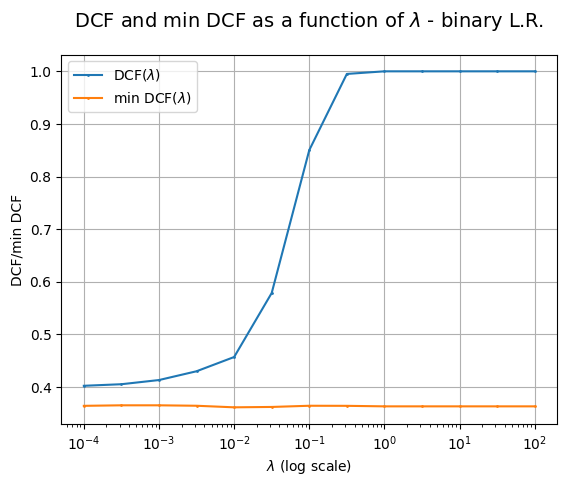

In [10]:
#plot the minDCF and DCF as a function of lambda
#use a log scale for the x-axis
plt.figure()
plt.xscale('log', base=10)
#set y-axis as DCF and minDCF
series0_yAxis = [DCF_l[lam] for lam in lambdas]
series1_yAxis = [minDCF_l[lam] for lam in lambdas]

#set x-axis as lambda
xAxis = lambdas


plt.plot(xAxis, series0_yAxis, marker='o', linestyle='-', markersize=1, label=f'DCF($\lambda$)')
plt.plot(xAxis, series1_yAxis, marker='o', linestyle='-', markersize=1, label=f'min DCF($\lambda$)')

plt.xlabel('$\lambda$ (log scale)')
plt.ylabel('DCF/min DCF')
plt.grid(True)
plt.legend()
plt.title('DCF and min DCF as a function of $\lambda$ - binary L.R.', fontsize=14, pad= 20)


Let's recall that the values of $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ are the normalized empirical Bayes Risk we would obtain with a **perfect score calibration** using the application $(\pi_T, C_{fn}, C_{fp}) = (0.1, 1, 1)$, so the best possible performance for a given set of scores if you could perfectly calibrate them for the target application parameters. <br>
Let's also recall that, based on what we obtain as $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ or $\text{DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$, we can actually say if our system is *good / useful* or *harmful /useless*:
- if $\text{(min) DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp}) > 1 \Rightarrow$ our system is **harmful**
- if $\text{(min) DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp}) > 1 \Rightarrow$ our system is **good**


So, we can say that all the $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ are below $1$ so the systems, with perfect score calibration, are all good and useful. <br> <br>
However, if we compare the $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ with the $\text{DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$, we can analyze a **significant loss due to poor score calibration**. <br> **This loss increases for higher values of the regularization term**, $\lambda$! In fact, the actual $\text{DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ increases almost exponentially (so, pretty fast) for values of $\lambda$ approximately going from $10^{-3}$ to $2 \cdot 10^{-1}$. Then, for higher values of $\lambda$, let's say for $\lambda > 2 \cdot 10^{-1}$, the we can observe a **plateau** in actual $\text{DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$, at around $1$. This means that the system is not so good for these values, because it performs almost as well as a  *dummy* system which performs classification just relying on the priors, not using the learned scores! <br>
So, to summarize, **the regularization term widely affects the two metrics, and has a strong impact on the score calibration!** As a matter of facts, if **$\lambda$ is too high, the classes separation gets bad and the score gets very misscalibrated!** The widening gap between the two metrics directy shows the impact of the regularization term on the calibration. <br>
To explain the cause of this behavior, I personally think that the fixed approach of subtracting the training set empirical prior log odds and then thresholding with the application prior log odds, used to adapt the binary L.R. model to our application prior $\pi_T = 0.1$, is **highly ineffective** for high values of $\lambda$.